In [18]:
# НОРМАЛЬНАЯ ВЕРСИЯ ИЗ АВТО
import datetime
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import KernelPCA
import numpy as np
import pandas as pd
import math
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
tf.random.set_seed(99)
tf.compat.v1.enable_eager_execution() #используете Eager execution (режим немедленного выполнения
from sklearn.metrics import *
import csv


# neurons_number= [60,30,20,10,5,1] - 200,150, 100

# steps = [ 50, 30, 20]  - 100,



In [19]:

# ПАРАМЕТРЫ
secid = 'TASB'
neurons_number = 20
window = 16
num_param= 13
drop_out= 0.0
steps = 50
name = secid+ '_lstm_' + 'n'+str(neurons_number) + 'win'+str(window)+ 'd'+ str(drop_out).replace('.','_')+'fullSteps'+ str(steps) +'np' + str(num_param) + '.csv'

name2 =secid+ '_lstm_' + 'n'+str(neurons_number) + 'win'+str(window)+ 'd'+ str(drop_out).replace('.','_')+'fullSteps'+ str(steps) +'np' + str(num_param)

num_lerning = steps

In [20]:

with open('file_for_output/hour_metrics/LSTM/'+name, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['rmse_lstm', 'mae_lstm', 'mape_lstm', 'r2_lstm', 'msle_lstm'])




# Здесь НАЧНЁМ подготваливать свои данные
dataFrame = pd.read_csv('file_for_input/all_hour/TASB_tradestats_test_hour.csv ')
dataFrame['tradedate'] = dataFrame['tradedate'] + '-' + dataFrame['tradetime_hour'].astype(str)
dataFrame = dataFrame.drop('tradetime_hour', axis=1)
dataFrame = dataFrame.rename(columns={'tradedate': 'Date'})
dataFrame = dataFrame.rename(columns={'pr_close_hour': 'Close'})
dataFrame = dataFrame.rename(columns={'pr_open_hour': 'Open'})
print(dataFrame)
print(dataFrame.columns)
print(dataFrame.head(n=2))
print("KONEC -----------------------------------")

# Здесь ЗАКОНЧИМ подготваливать свои данные

#Data preprocessing
imputer = SimpleImputer(missing_values=np.nan) # Handling missing values
dataFrame.drop(columns=['Date'], inplace=True)
dataFrame = pd.DataFrame(imputer.fit_transform(dataFrame), columns=dataFrame.columns)
dataFrame = dataFrame.reset_index(drop=True)
# Applying feature scaling
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(dataFrame.to_numpy())
df_scaled = pd.DataFrame(df_scaled, columns=list(dataFrame.columns))
target_scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled[['Open', 'Close']] = target_scaler.fit_transform(dataFrame[['Open', 'Close']].to_numpy())
df_scaled = df_scaled.astype(float)
# df_scaled = dataFrame.astype(float)


# Здесь начнём добавлять тестовую выборку
# вычисляем количество строк, которое соответствует 10% от общего количества строк
n = int(len(dataFrame) * 0.10)
# выбираем последние n строк
df_test = dataFrame.iloc[-n:]
dataFrame= dataFrame.iloc[:-n] # Убираем последние n% строк из основного датасета
# Здесь нЗакончим создавать тестовую выборку






# Single step dataset preparation
def singleStepSampler(df, window):
	xRes = []
	yRes = []
	for i in range(0, len(df) - window):
		res = []
		for j in range(0, window):
			r = []
			for col in df.columns:
				r.append(df[col][i + j])
			res.append(r)
		xRes.append(res)
		yRes.append(df[['Open', 'Close']].iloc[i + window].values)
	return np.array(xRes), np.array(yRes)

# Dataset splitting
SPLIT = 0.85
(xVal, yVal) = singleStepSampler(df_scaled, window) # было (xVal, yVal) = singleStepSampler(df_scaled, 20)
print("Кол-во данных после сплитинга ",len(xVal),len(yVal))


X_final_test = xVal[int(SPLIT * len(xVal)):]
y_final_test = yVal[int(SPLIT * len(yVal)):]
xVal = xVal[:int(SPLIT * len(xVal))]
yVal = yVal[:int(SPLIT * len(yVal))]
print("длина X_final_test,y_final_test ",len(X_final_test),len(y_final_test))
print("Кол-во данных после X_final_test ",len(xVal),len(yVal))


X_train = xVal[:int(SPLIT * len(xVal))]
y_train = yVal[:int(SPLIT * len(yVal))]
X_test = xVal[int(SPLIT * len(xVal)):]
y_test = yVal[int(SPLIT * len(yVal)):]
print("(обычное обучение)Кол-во данных  X_train, y_train ",len(X_train),len(y_train))
print("(обычное обучение)Кол-во данных  X_test, y_test ",len(X_test),len(y_test))



               Date   vol       val  trades  trades_b  trades_s     val_b  \
0     2020-01-03-11   1.0    2745.0     1.0       0.0       1.0       0.0   
1     2020-01-03-13   1.0    2745.0     1.0       0.0       1.0       0.0   
2     2020-01-08-10   1.0    2720.0     1.0       0.0       1.0       0.0   
3     2020-01-08-13   6.0   16610.0     4.0       2.0       2.0   11070.0   
4     2020-01-08-14   2.0    5460.0     2.0       0.0       2.0       0.0   
...             ...   ...       ...     ...       ...       ...       ...   
5773  2023-10-31-14  40.0  103965.0    27.0      21.0       6.0   78232.0   
5774  2023-10-31-15  31.0   80665.0     6.0       4.0       2.0   31237.0   
5775  2023-10-31-16  65.0  170079.0     8.0       8.0       0.0  170079.0   
5776  2023-10-31-17  15.0   38794.0     9.0       2.0       7.0    5198.0   
5777  2023-10-31-18   7.0   18193.0     6.0       6.0       0.0   18193.0   

        val_s  vol_b  vol_s    Open   Close  pr_high_hour  pr_low_hour  
0 

In [21]:

for i in range(steps):	
	
	
	multivariate_lstm = keras.Sequential()
	multivariate_lstm.add(keras.layers.LSTM(neurons_number, input_shape=(X_train.shape[1], X_train.shape[2])))
	multivariate_lstm.add(keras.layers.Dropout(drop_out))
	multivariate_lstm.add(keras.layers.Dense(2, activation='linear'))
	multivariate_lstm.compile(loss='mae', metrics=['mse'], optimizer='adam') # Было: metrics=['mae']
	multivariate_lstm.summary()
    
    
	history = multivariate_lstm.fit(X_train, y_train, epochs=(i+1))#,validation_split=0.4
	
	# Forecast Plot with Dates on X-axis
	predicted_values = multivariate_lstm.predict(X_test)
	
	d = {
		'Predicted_Open': predicted_values[:, 0],
		'Predicted_Close': predicted_values[:, 1],
		'Actual_Open': y_test[:, 0],
		'Actual_Close': y_test[:, 1],
	}
	
	d = pd.DataFrame(d)
	d.index = dataFrame.index[-len(y_test):] # Assigning the correct date index
	
	# fig, ax = plt.subplots(figsize=(10, 6))
	# highlight the forecast
	# highlight_start = int(len(d) * 0.9)
	# highlight_end = len(d) - 1 # Adjusted to stay within bounds
	# Plot the actual values
	# plt.plot(d[['Actual_Close']][:highlight_start], label=['Actual_Close'])
	#
	# # Plot predicted values with a dashed line
	# plt.plot(d[['Predicted_Close']], label=['Predicted_Close'], linestyle='--')
	#
	# # Highlight the forecasted portion with a different color
	# plt.axvspan(d.index[highlight_start], d.index[highlight_end], facecolor='lightgreen', alpha=0.5, label='Forecast')
	#
	# #  ГРАфик предсказаных значений
	# plt.title('LSTM')
	# plt.xlabel('Dates')
	# plt.ylabel('Values')
	# ax.legend()
	# plt.show()
	#
	#
	#
	# # Построение графика зависимости потерь от эпохи
	# plt.figure(figsize=(10, 6))
	# plt.plot(history.history['loss'], label='Training Loss')
	# plt.plot(history.history['mse'], label='MSE')
	# plt.title('Model Training')
	# plt.ylabel('Loss/MSE')
	# plt.xlabel('Epoch')
	# plt.legend()
	# plt.savefig('file_for_output/hour_metrics/LSTM/graphics/'+name+'graph_learn.png', bbox_inches='tight')
	# plt.show()
    
	# Model Evaluation  МЕТРИКИ МОДЕЛИ
	def eval(model):
		return {
			'MSE': sklearn.metrics.mean_squared_error(d[f'Actual_{model.split("_")[1]}'].to_numpy(), d[model].to_numpy()),
			'MAE': sklearn.metrics.mean_absolute_error(d[f'Actual_{model.split("_")[1]}'].to_numpy(), d[model].to_numpy()),
			'R2': sklearn.metrics.r2_score(d[f'Actual_{model.split("_")[1]}'].to_numpy(), d[model].to_numpy())
		}
	
	result = dict()
	
	for item in ['Predicted_Close']:
		result[item] = eval(item)
	
	print(result)
	
	# комментарий
	# Начинаем работу с X_final_test Y_final_test
	
	y_pred_final_test = multivariate_lstm.predict(X_final_test) # Предсказываем значения
	
	
	# Оценка для ДИПЛОМА
	rmse_lstm = root_mean_squared_error(y_final_test, y_pred_final_test)
	mae_lstm = mean_absolute_error(y_final_test, y_pred_final_test)
	mape_lstm = mean_absolute_percentage_error(y_final_test, y_pred_final_test)
	r2_lstm = r2_score(y_final_test, y_pred_final_test)
	# msle_lstm = mean_squared_log_error(y_final_test, y_pred_final_test)
	msle_lstm=0
	
	# оздайте DataFrame для хранения фактических и предсказанных значений:
	
	d_final_test = pd.DataFrame({
		'Actual_Open': y_final_test[:, 0],
		'Actual_Close': y_final_test[:, 1],
		'Predicted_Open': y_pred_final_test[:, 0],
		'Predicted_Close': y_pred_final_test[:, 1]
	})
	
	# # Рисуем график фактических и предсказанных значений:
	# plt.figure(figsize=(10, 6))
	# 
	# plt.plot(d_final_test['Actual_Close'], label='Actual Close')
	# plt.plot(d_final_test['Predicted_Close'], label='Predicted Close')
	# 
	# plt.title('LSTM Model - Actual vs. Predicted')
	# plt.xlabel('Time')
	# plt.ylabel('Close Price')
	# plt.legend()
	# plt.savefig('file_for_output/hour_metrics/LSTM/graphics/'+name+'graph_full.png', bbox_inches='tight')
	# plt.show()
	
	with open('file_for_output/hour_metrics/LSTM/'+name, 'a', newline='') as csvfile:
		writer = csv.writer(csvfile)
		writer.writerow([rmse_lstm, mae_lstm, mape_lstm, r2_lstm, msle_lstm])
	
	
	print(" Название сохранённого файла: "+ name)
	


C:\TRADE_LapTop\KanNootebook\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_100 (LSTM)                 │ (None, 20)             │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_100 (Dropout)           │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 2)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,762 (10.79 KB)

 Trainable params: 2,762 (10.79 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_149 (LSTM)                 │ (None, 20)             │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_149 (Dropout)           │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_149 (Dense)               │ (None, 2)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,762 (10.79 KB)

 Trainable params: 2,762 (10.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0237 - mse: 0.0014
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0025 - mse: 1.4494e-05
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0022 - mse: 1.2074e-05
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0021 - mse: 1.1332e-05
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0020 - mse: 1.0494e-05
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0019 - mse: 9.9148e-06
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0019 - mse: 9.7310e-06
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0020 - mse: 9.9688e-06
Epoch 9/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0018 - mse: 9.1967e-06
Epoch 10/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0019 - mse: 9.5217e-06
Epoch 11/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0018 - mse: 9.1016e-06
Epoch 12/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0019

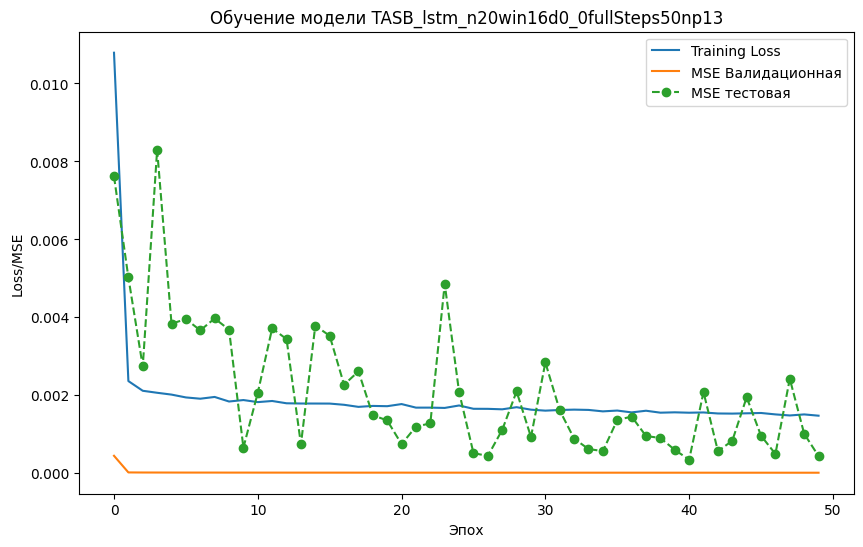

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка метрик из CSV
metrics_df = pd.read_csv('file_for_output/hour_metrics/LSTM/'+name)

# Вычисление MSE из RMSE
metrics_df['mse_lstm'] = metrics_df['rmse_lstm'] ** 2

# Построение графика
plt.figure(figsize=(10, 6))

# Добавление данных из истории обучения
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['mse'], label='MSE Валидационная')

# Добавление данных MSE, рассчитанных из RMSE
plt.plot(metrics_df['mse_lstm'], label='MSE тестовая', linestyle='--', marker='o')

# Настройка графика
plt.title('Обучение модели '+ name2)
plt.ylabel('Loss/MSE')
plt.xlabel('Эпох')
plt.legend()
plt.savefig('file_for_output/hour_metrics/LSTM/graphics/' + name + 'graph_learn.png', bbox_inches='tight')
plt.show()

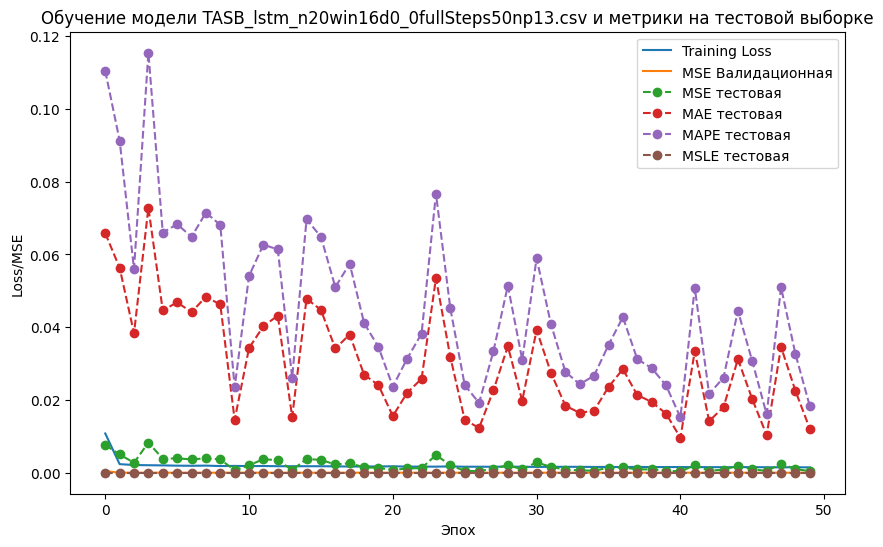

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка метрик из CSV
metrics_df = pd.read_csv('file_for_output/hour_metrics/LSTM/'+name)

# Вычисление MSE из RMSE
metrics_df['mse_lstm'] = metrics_df['rmse_lstm'] ** 2

# Построение графика
plt.figure(figsize=(10, 6))

# Добавление данных из истории обучения
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['mse'], label='MSE Валидационная')

# Добавление данных других метрик
plt.plot(metrics_df['mse_lstm'], label='MSE тестовая', linestyle='--', marker='o')
plt.plot(metrics_df['mae_lstm'], label='MAE тестовая', linestyle='--', marker='o')
plt.plot(metrics_df['mape_lstm'], label='MAPE тестовая', linestyle='--', marker='o')
# plt.plot(metrics_df['r2_lstm'], label='R2 тестовая', linestyle='--', marker='o')
plt.plot(metrics_df['msle_lstm'], label='MSLE тестовая', linestyle='--', marker='o')

# Настройка графика
plt.title('Обучение модели '+ name+ ' и метрики на тестовой выборке')
plt.ylabel('Loss/MSE')
plt.xlabel('Эпох')
plt.legend()
plt.savefig('file_for_output/hour_metrics/LSTM/graphics/' + name + 'graph_learn_fullMetrics.png', bbox_inches='tight')
plt.show()